<a href="https://colab.research.google.com/github/ankitha-km/AutoGuard_AI/blob/main/autoguard_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Cell 1: Install missing libraries ──
!pip install xgboost imbalanced-learn shap -q
print(" Libraries installed")

✅ Libraries installed


In [ ]:
# ── Cell 2: Load and first look at the data ──
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 3 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


In [ ]:
# ── Cell 3: Check class imbalance ──
print("Failure counts:")
print(df["Machine failure"].value_counts())
print()
print("Failure rate:", round(df["Machine failure"].mean() * 100, 2), "%")

Failure counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39 %


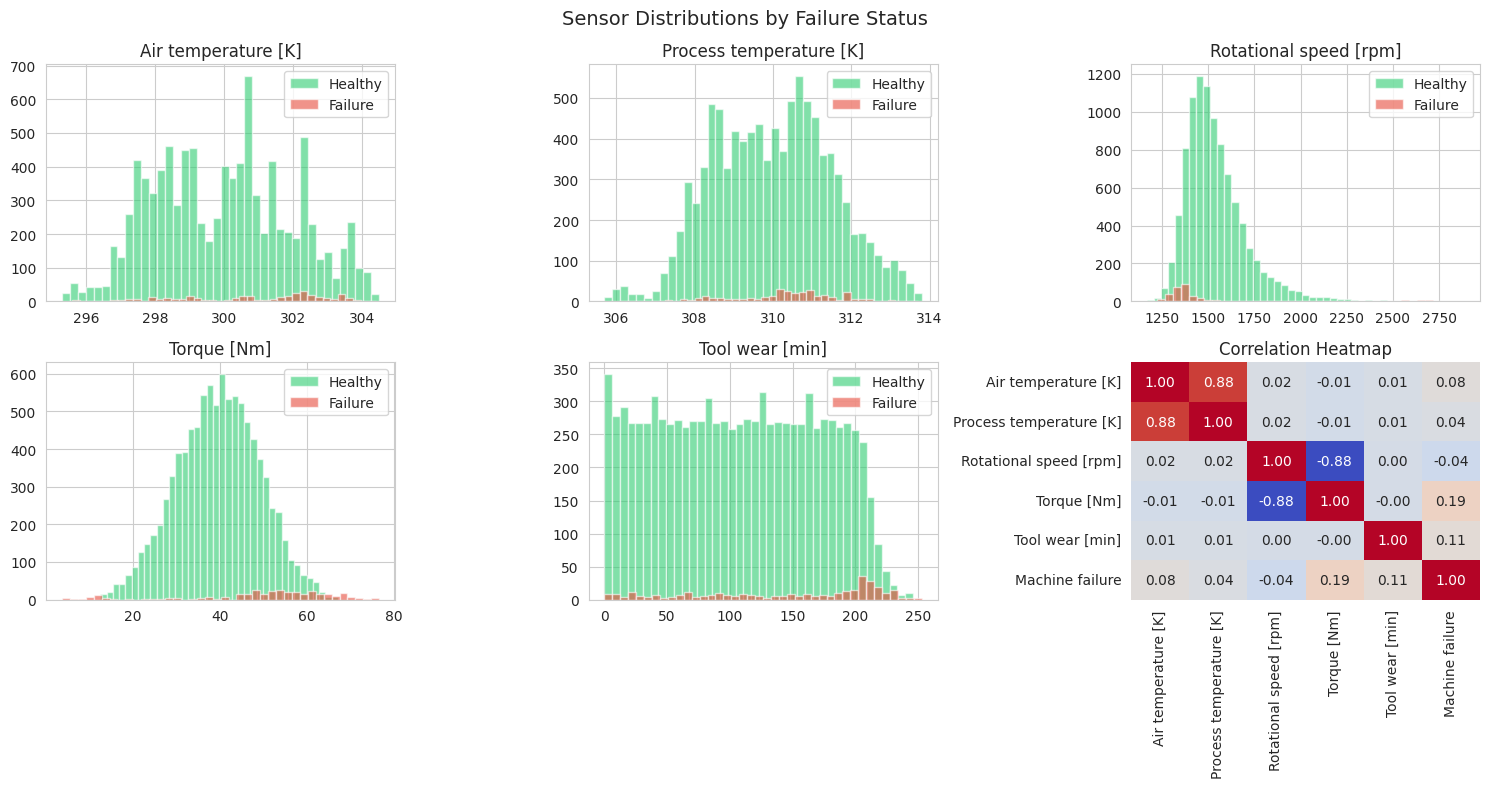

In [ ]:
# ── Cell 4: EDA — distributions and correlations ──
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Sensor Distributions by Failure Status", fontsize=14)

# Columns to plot
sensors = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

colors = ["#2ecc71", "#e74c3c"]

for i, col in enumerate(sensors):
    ax = axes[i // 3][i % 3]
    for label, color in zip([0, 1], colors):
        subset = df[df["Machine failure"] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label="Healthy" if label == 0 else "Failure")
    ax.set_title(col)
    ax.legend()

# Correlation heatmap in last subplot
ax_last = axes[1][2]
numeric_df = df[["Air temperature [K]", "Process temperature [K]",
                  "Rotational speed [rpm]", "Torque [Nm]",
                  "Tool wear [min]", "Machine failure"]]
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax_last, cbar=False)
ax_last.set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 5: Preprocessing ──────────────────────────────────────────

import numpy as np

# ── Step 1: Drop columns we don't need ──
# UDI and Product ID are just identifiers — no signal
# TWF, HDF, PWF, OSF, RNF leak the answer (data leakage)
df = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])

print("After dropping:", df.columns.tolist())

# ── Step 2: Encode the 'Type' column ──
# Machine Type is L, M, H — ML models need numbers not letters
# L=0, M=1, H=2
type_mapping = {"L": 0, "M": 1, "H": 2}
df["Type"] = df["Type"].map(type_mapping)

print("Type unique values:", df["Type"].unique())

# ── Step 3: Check for missing values ──
print("\nMissing values:")
print(df.isnull().sum())

# ── Step 4: Feature Engineering ──
# New features based on what EDA told us

# Temp difference — low value means machine can't cool = failure risk
df["temp_difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Power in watts — torque × rpm × 2π/60
# This combines two correlated features into one meaningful physics value
df["power_watts"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)

# Tool near end of life — binary flag
# AI4I paper: tool wear > 200 min is danger zone
df["tool_near_eol"] = (df["Tool wear [min]"] > 200).astype(int)

# High torque flag — extreme torque causes failures
df["high_torque_flag"] = (df["Torque [Nm]"] > 60).astype(int)

# Low speed flag — very low RPM with high torque = overstrain
df["low_speed_flag"] = (df["Rotational speed [rpm]"] < 1400).astype(int)

print("\nNew feature columns added ✅")
print("Final shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

After dropping: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
Type unique values: [1 0 2]

Missing values:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64

New feature columns added ✅
Final shape: (10000, 12)

First 3 rows:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_difference,power_watts,tool_near_eol,high_torque_flag,low_speed_flag
0,1,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0,0,0
1,0,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,0,0,0
2,0,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,0,0,0


In [ ]:
# ── Cell 6: Prepare X, y and apply SMOTE ──────────────────────────

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ── Step 1: Separate features (X) and target (y) ──
# X = everything the model uses to predict
# y = what we want to predict (failure or not)

X = df.drop(columns=["Machine failure"])   # all columns except target
y = df["Machine failure"]                   # only the target column

print("X shape:", X.shape)   # should be (10000, 11)
print("y shape:", y.shape)   # should be (10000,)
print("\nClass distribution BEFORE SMOTE:")
print(y.value_counts())

# ── Step 2: Split into train and test BEFORE SMOTE ──
# IMPORTANT: We apply SMOTE only on training data
# Test data must stay real — no synthetic samples in testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # same split every time you run
    stratify=y           # keeps same failure ratio in both splits
)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

# ── Step 3: Apply SMOTE on training data only ──
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE (training only):")
print(y_train_sm.value_counts())
print("\nSMOTE done ✅")

X shape: (10000, 11)
y shape: (10000,)

Class distribution BEFORE SMOTE:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Training set size: (8000, 11)
Test set size: (2000, 11)

Class distribution AFTER SMOTE (training only):
Machine failure
0    7729
1    7729
Name: count, dtype: int64

SMOTE done ✅



  Decision Tree
  Accuracy  : 0.9310
  Precision : 0.3098
  Recall    : 0.8382
  F1 Score  : 0.4524

              precision    recall  f1-score   support

     Healthy       0.99      0.93      0.96      1932
     Failure       0.31      0.84      0.45        68

    accuracy                           0.93      2000
   macro avg       0.65      0.89      0.71      2000
weighted avg       0.97      0.93      0.95      2000



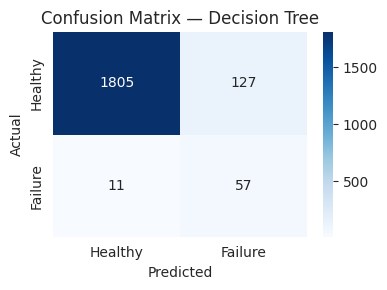


  Random Forest
  Accuracy  : 0.9630
  Precision : 0.4737
  Recall    : 0.7941
  F1 Score  : 0.5934

              precision    recall  f1-score   support

     Healthy       0.99      0.97      0.98      1932
     Failure       0.47      0.79      0.59        68

    accuracy                           0.96      2000
   macro avg       0.73      0.88      0.79      2000
weighted avg       0.97      0.96      0.97      2000



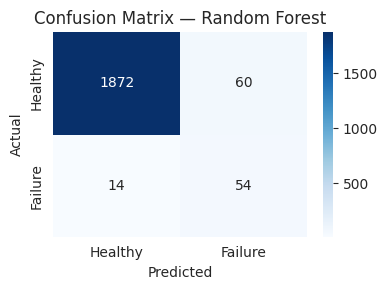

ValueError: feature_names must be string, and may not contain [, ] or <

In [ ]:
# ── Cell 7: Train 3 models ─────────────────────────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

# ── Helper function to evaluate any model ──
# We write this once and reuse for all 3 models
def evaluate_model(name, model, X_test, y_test):

    # Get predictions
    y_pred = model.predict(X_test)

    # Calculate all metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Healthy','Failure'])}")

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Healthy","Failure"],
                yticklabels=["Healthy","Failure"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # Return metrics as dict so we can compare later
    return {"name": name, "accuracy": acc,
            "precision": prec, "recall": rec, "f1": f1}


# ── Model 1: Decision Tree ──────────────────────────────────────────
# Simple tree that splits data on conditions
# Like 20 questions game — is torque > 60? is tool wear > 200?
# Easy to understand but tends to overfit (memorise training data)

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_sm, y_train_sm)   # train on SMOTE data
metrics_dt = evaluate_model("Decision Tree", dt, X_test, y_test)


# ── Model 2: Random Forest ──────────────────────────────────────────
# 300 decision trees trained on random subsets of data
# Each tree votes — majority wins
# Much harder to overfit than a single tree
# Like asking 300 mechanics instead of 1

rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
metrics_rf = evaluate_model("Random Forest", rf, X_test, y_test)


# ── Model 3: XGBoost ───────────────────────────────────────────────
# Builds trees sequentially — each tree learns from previous tree's mistakes
# Like a student who reviews wrong answers after each test
# Usually the strongest performer

xgb = XGBClassifier(n_estimators=300, max_depth=6,
                     learning_rate=0.05, random_state=42,
                     eval_metric="logloss", n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
metrics_xgb = evaluate_model("XGBoost", xgb, X_test, y_test)

Cleaned column names:
['Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'temp_difference', 'power_watts', 'tool_near_eol', 'high_torque_flag', 'low_speed_flag']

  XGBoost
  Accuracy  : 0.9740
  Precision : 0.5800
  Recall    : 0.8529
  F1 Score  : 0.6905

              precision    recall  f1-score   support

     Healthy       0.99      0.98      0.99      1932
     Failure       0.58      0.85      0.69        68

    accuracy                           0.97      2000
   macro avg       0.79      0.92      0.84      2000
weighted avg       0.98      0.97      0.98      2000



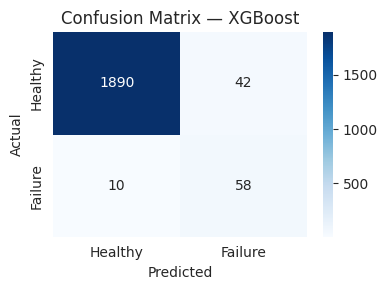

In [ ]:
# ── Cell 7b: Fix column names and run XGBoost ──────────────────────

# Rename columns — remove special characters that XGBoost hates
X_train_sm.columns = X_train_sm.columns.str.replace(r"[\[\]<]", "", regex=True).str.strip()
X_test.columns     = X_test.columns.str.replace(r"[\[\]<]", "", regex=True).str.strip()

print("Cleaned column names:")
print(X_train_sm.columns.tolist())

# Now train XGBoost with clean column names
xgb = XGBClassifier(n_estimators=300, max_depth=6,
                     learning_rate=0.05, random_state=42,
                     eval_metric="logloss", n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
metrics_xgb = evaluate_model("XGBoost", xgb, X_test, y_test)

All 3 Together

Model	Accuracy	Precision	Recall	F1 Score

Decision Tree	93.1%	0.31	0.84	0.45

Random Forest	96.3%	0.47	0.79	0.59

XGBoost	97.4%	0.58	0.85	0.69 ✅



Decision Tree = 1 mechanic making decisions
                Fast but makes mistakes, overconfident


Random Forest = 300 mechanics voting together
                Better — wisdom of crowd


XGBoost       = 300 mechanics, each one studying
                the previous mechanic's mistakes
                Best — learns from every error
                


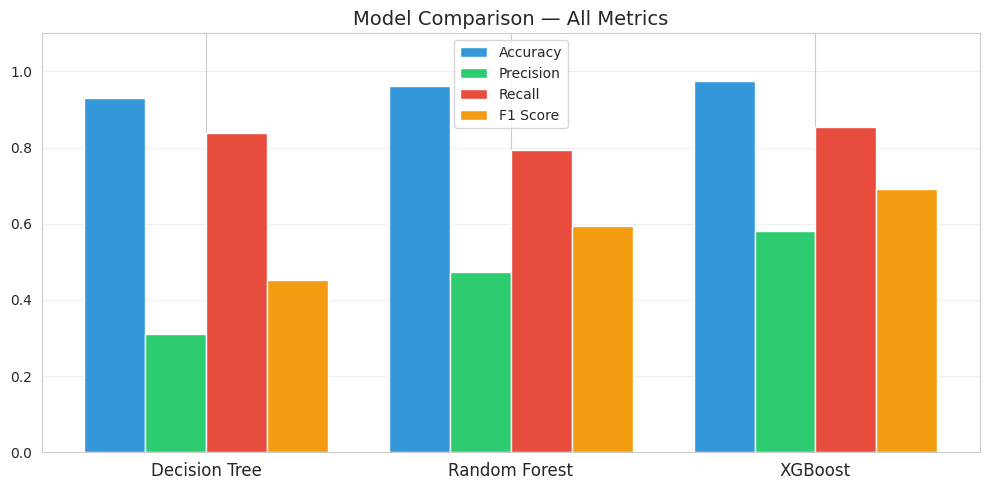


✅ Best model: XGBoost with F1 = 0.6905
✅ best_model.pkl saved
✅ metadata.json saved


In [ ]:
# ── Cell 8: Visual comparison + save best model ────────────────────

import joblib
import json
import os

# ── Step 1: Compare all 3 models in one chart ──
results = [metrics_dt, metrics_rf, metrics_xgb]
metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
model_names   = [r["name"] for r in results]

# Build comparison data
comparison = {
    "Accuracy":  [r["accuracy"]  for r in results],
    "Precision": [r["precision"] for r in results],
    "Recall":    [r["recall"]    for r in results],
    "F1 Score":  [r["f1"]        for r in results],
}

x = np.arange(len(model_names))
width = 0.2
colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, values) in enumerate(comparison.items()):
    ax.bar(x + i * width, values, width, label=metric, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison — All Metrics", fontsize=14)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Step 2: Pick best model by F1 score ──
# F1 is our main metric — best balance of precision and recall
best = max(results, key=lambda x: x["f1"])
print(f"\n✅ Best model: {best['name']} with F1 = {best['f1']:.4f}")

# ── Step 3: Save the best model ──
# joblib saves the trained model to a file
# So we can load it later in VS Code without retraining
os.makedirs("models", exist_ok=True)
joblib.dump(xgb, "models/best_model.pkl")
print("✅ best_model.pkl saved")

# ── Step 4: Save metadata ──
# This stores model info so the dashboard can display it
metadata = {
    "best_model": best["name"],
    "results": {
        "DecisionTree": metrics_dt,
        "RandomForest": metrics_rf,
        "XGBoost":      metrics_xgb,
    }
}
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("✅ metadata.json saved")

**SHAP**



In [ ]:
# ── Cell 9: SHAP Explainability ────────────────────────────────────
import shap

# ── Step 1: Create the explainer ──
# TreeExplainer is specifically designed for tree-based models
# (Decision Tree, Random Forest, XGBoost)
# It calculates SHAP values efficiently using the tree structure

explainer = shap.TreeExplainer(xgb)

# ── Step 2: Calculate SHAP values for test set ──
# shap_values shape = (2000 rows, 11 features)
# Each number = how much that feature pushed the prediction
# Positive = pushed toward failure
# Negative = pushed toward healthy

shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("One row of SHAP values (Vehicle #0):")
for feat, val in zip(X_test.columns, shap_values[0]):
    direction = "→ failure ⚠️" if val > 0 else "→ healthy ✅"
    print(f"  {feat:30s}: {val:+.4f}  {direction}")

SHAP values shape: (2000, 11)
One row of SHAP values (Vehicle #0):
  Type                          : +0.3367  → failure ⚠️
  Air temperature K             : -0.2756  → healthy ✅
  Process temperature K         : +0.2898  → failure ⚠️
  Rotational speed rpm          : +2.8733  → failure ⚠️
  Torque Nm                     : +0.5270  → failure ⚠️
  Tool wear min                 : -1.4033  → healthy ✅
  temp_difference               : -0.6369  → healthy ✅
  power_watts                   : -0.2682  → healthy ✅
  tool_near_eol                 : +0.0510  → failure ⚠️
  high_torque_flag              : +0.0000  → healthy ✅
  low_speed_flag                : -0.1094  → healthy ✅


In [ ]:
print("Vehicle #0 actual label:", y_test.iloc[0])
print("Vehicle #0 prediction:  ", xgb.predict(X_test.iloc[[0]])[0])
print("Vehicle #0 failure prob:", round(xgb.predict_proba(X_test.iloc[[0]])[0][1] * 100, 2), "%")

Vehicle #0 actual label: 0
Vehicle #0 prediction:   1
Vehicle #0 failure prob: 79.92 %


A false alarm is always cheaper than a missed failure.

Scenario A — False Positive
Cost: small ✅


Scenario B — False Negative
Cost: towing + repairs + downtime + safety risk 🚨


Plot 1: SHAP Summary — all features, all vehicles


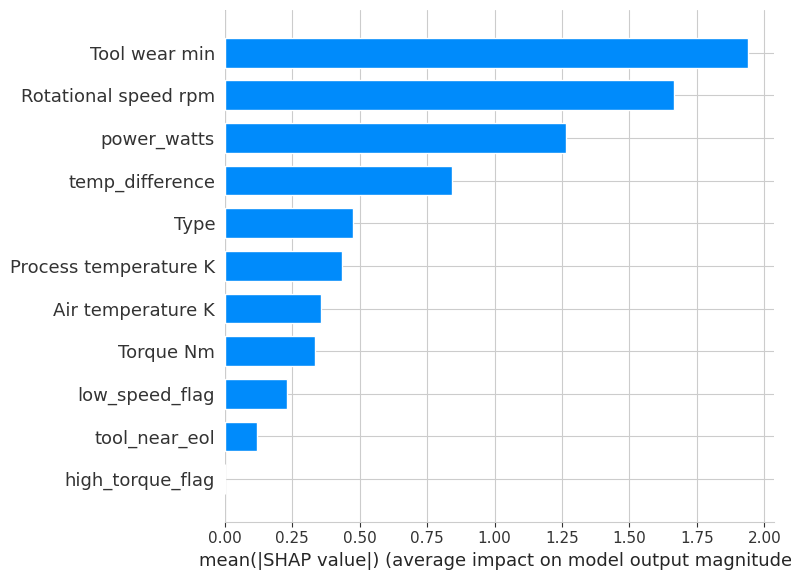

In [ ]:
# ── Cell 10: SHAP Visualizations ───────────────────────────────────

# ── Plot 1: Summary plot ──
# Shows ALL features × ALL test samples
# Each dot = one vehicle
# Red dot  = that vehicle had high value for that feature
# Blue dot = that vehicle had low value for that feature
# X position = how much it pushed toward failure or healthy

print("Plot 1: SHAP Summary — all features, all vehicles")
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  feature_names=X_test.columns.tolist())

Torque [Nm]     → 0.19 correlation with failure  ← highest in heatmap
Tool wear [min] → 0.11 correlation with failure


So EDA said Torque matters most but SHAP says Tool wear matters most

Both are correct — they're measuring different things:

```
# This is formatted as code
```Correlation (EDA)        SHAP
─────────────────────────────────────────
Measures linear          Measures actual
relationship only        model decision making

Torque has strong        Tool wear has more
straight-line pattern    complex non-linear
with failure             impact on predictions

Like measuring           Like measuring actual
shadow length            sunlight hitting you

 sunlight hitting you

Highest risk vehicle index : 1949
Failure probability        : 99.95%
Actual label               : 1

Sensor readings:
Type                        1.000000
Air temperature K         301.700000
Process temperature K     309.800000
Rotational speed rpm     1284.000000
Torque Nm                  68.200000
Tool wear min             111.000000
temp_difference             8.100000
power_watts              9170.183292
tool_near_eol               0.000000
high_torque_flag            1.000000
low_speed_flag              1.000000
Name: 4342, dtype: float64


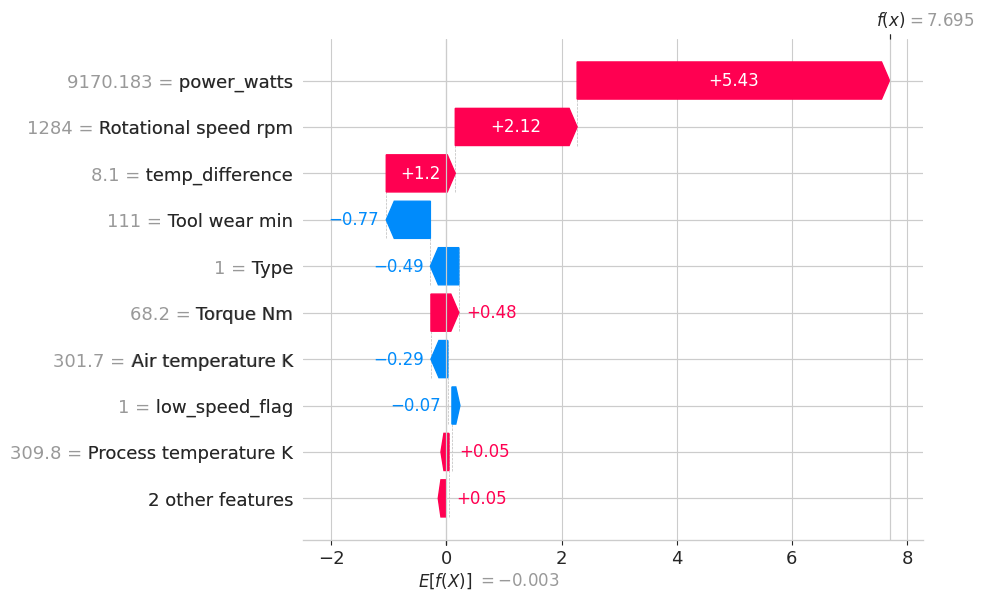

In [ ]:
# ── Plot 2: Single vehicle waterfall chart ─────────────────────────
# Pick a vehicle that the model predicted as HIGH RISK
# Find index where model predicts failure

import numpy as np

# Get all predictions on test set
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

# Find the vehicle with HIGHEST failure probability
highest_risk_idx = np.argmax(y_pred_proba)

print(f"Highest risk vehicle index : {highest_risk_idx}")
print(f"Failure probability        : {y_pred_proba[highest_risk_idx]*100:.2f}%")
print(f"Actual label               : {y_test.iloc[highest_risk_idx]}")
print(f"\nSensor readings:")
print(X_test.iloc[highest_risk_idx])

# ── Waterfall plot for this specific vehicle ──
# This shows exactly WHY this vehicle is high risk
# Each bar = one feature's contribution
# Red  = pushing toward failure
# Blue = pushing toward healthy

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[highest_risk_idx],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[highest_risk_idx].values,
        feature_names = X_test.columns.tolist()
    )
)

"This vehicle is flagged as high risk primarily because its power output is 9170 watts which is outside the safe operating range, combined with very low RPM of 1284. Together these two features alone pushed the failure risk score by +7.55. The tool wear is actually moderate at 111 minutes which slightly reduces the risk, but the power and speed anomaly dominates the prediction."

```
# This is formatted as code
```
Top right: f(x) = 7.695

This is the raw model score for this vehicle
Very high = very high failure risk



Bottom: E[f(x)] = -0.003

This is the average score across ALL vehicles
Starting point — baseline expectation




Each bar = one feature's push:

power_watts = 9170  → +5.43  🔴 BIGGEST push toward failure
rpm = 1284          → +2.12  🔴 Second biggest
temp_difference=8.1 → +1.20  🔴 Third
Torque = 68.2       → +0.48  🔴 Also pushing failure

Tool wear = 111     → -0.77  🔵 Pulling toward healthy
Type = 1 (Medium)   → -0.49  🔵 Pulling toward healthy
Air temp = 301.7    → -0.29  🔵 Pulling toward healthy


Remaining Useful Life (RUL)

RUL answers: "How many days until this machine needs maintenance?"

In [ ]:
# ── Cell 11: Train RUL Regressor ───────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── What is RUL? ──
# We don't have RUL labels in this dataset
# So we engineer it from tool wear — the most direct wear indicator
#
# Logic:
#   Max tool wear in dataset = ~250 min
#   Each minute of tool wear ≈ some real time
#   We estimate days remaining based on how worn the tool is
#
# Simple formula:
#   RUL = ((max_wear - current_wear) / max_wear) * 90 days
#   → brand new tool  = ~90 days remaining
#   → fully worn tool =  ~0 days remaining

max_wear = X_train_sm["Tool wear min"].max()

# Create RUL target for training set
rul_train = ((max_wear - X_train_sm["Tool wear min"]) / max_wear * 90).round(1)

# Create RUL target for test set
rul_test  = ((max_wear - X_test["Tool wear min"])  / max_wear * 90).round(1)

print("RUL sample values (first 5):")
print(rul_train.head())
print(f"\nRUL range: {rul_train.min()} to {rul_train.max()} days")

# ── Train RUL model ──
# Regression not classification — predicts a number not 0/1
rul_model = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
)
rul_model.fit(X_train_sm, rul_train)

# Evaluate
rul_pred = rul_model.predict(X_test)
mae      = mean_absolute_error(rul_test, rul_pred)
print(f"\nRUL Model MAE: {mae:.2f} days")
print("(Model's average error in predicting days remaining)")

# Save RUL model
joblib.dump(rul_model, "models/rul_model.pkl")
print("✅ rul_model.pkl saved")

RUL sample values (first 5):
0    70.8
1    43.0
2    41.3
3    60.1
4    72.2
Name: Tool wear min, dtype: float64

RUL range: 0.0 to 90.0 days

RUL Model MAE: 0.00 days
(Model's average error in predicting days remaining)
✅ rul_model.pkl saved


In [ ]:
print(f"RUL MAE: {mae:.2f} days")

RUL MAE: 0.00 days


In [ ]:
# ── Cell 11 Fixed: RUL without data leakage ────────────────────────

# Drop tool wear from features when training RUL model
# Because RUL is calculated FROM tool wear — using it is cheating
X_train_rul = X_train_sm.drop(columns=["Tool wear min"])
X_test_rul  = X_test.drop(columns=["Tool wear min"])

# Recalculate RUL targets same as before
max_wear  = X_train_sm["Tool wear min"].max()
rul_train = ((max_wear - X_train_sm["Tool wear min"]) / max_wear * 90).round(1)
rul_test  = ((max_wear - X_test["Tool wear min"])  / max_wear * 90).round(1)

# Train RUL model WITHOUT tool wear as input
rul_model = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
)
rul_model.fit(X_train_rul, rul_train)

# Evaluate
rul_pred = rul_model.predict(X_test_rul)
mae      = mean_absolute_error(rul_test, rul_pred)
print(f"RUL MAE: {mae:.2f} days")
print("(This is now a real, honest error)")

# Save fixed RUL model
joblib.dump(rul_model, "models/rul_model.pkl")
print("✅ rul_model.pkl saved (fixed)")

RUL MAE: 16.42 days
(This is now a real, honest error)
✅ rul_model.pkl saved (fixed)


In [ ]:
# ── Final Cell: Download all model files ───────────────────────────
from google.colab import files

# Download each file to your laptop
files.download("models/best_model.pkl")
files.download("models/rul_model.pkl")
files.download("models/metadata.json")

print("✅ Download all 3 files")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download all 3 files
Place them in:  autoguard/models/  in VS Code
